PROYECTO PARA EL MÓDULO DE MACHINE LEARNING. EN ESTE PROYECTO, TENEMOS QUE CREAR UN MODELO QUE NOS PERMITA AVERIGUAR QUÉ CLIENTE TIENE ALTA PROBABILIDAD DE CANCELAR.

In [1]:
#imports
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier


In [2]:
#importar fichero csv

df=pd.read_csv('../data/raw/reservas_hoteleras.csv')

# 0. INTRODUCCIÓN AL DATASET. 
## MOSTRAMOS LOS PRIMEROS DATOS PARA CONOCER EL DATASET: LAS COLUMNAS, LOS TIPOS DE DATOS...

In [3]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [4]:
#nombre de todas las columnas para conocer mejor el dataset
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

## CONOCEMOS UN POQUITO EL DATASET, VIENDO LOS NULOS Y LOS DUPLICADOS

In [6]:
#valores nulos. Es importante saber qué tipo de dato es para hacernos una idea de cómo lo trataremos más adelante 
def resumen_variables(df):
    resumen = pd.DataFrame({
        "dtype": df.dtypes,
        "nulos": df.isnull().sum(),
        "pct_nulos": df.isnull().mean() * 100,
        "n_unique": df.nunique()
    })
    return resumen[resumen["nulos"] > 0]
resumen_variables(df)

,dtype,nulos,pct_nulos,n_unique
children,float64,4,0.003350,5
country,object,488,0.408744,177
agent,float64,16340,13.686238,333
company,float64,112593,94.306893,352


In [7]:
#valores duplicados
duplicados=df.duplicated().sum()
print(f'Valores duplicados: {duplicados} ({(duplicados/len(df))*100:.2f}%)') 

Valores duplicados: 31994 (26.80%)


# 1. EDA y comprensión del negocio


## 1.1. Primeros gráficos. Entendiendo las cancelaciones

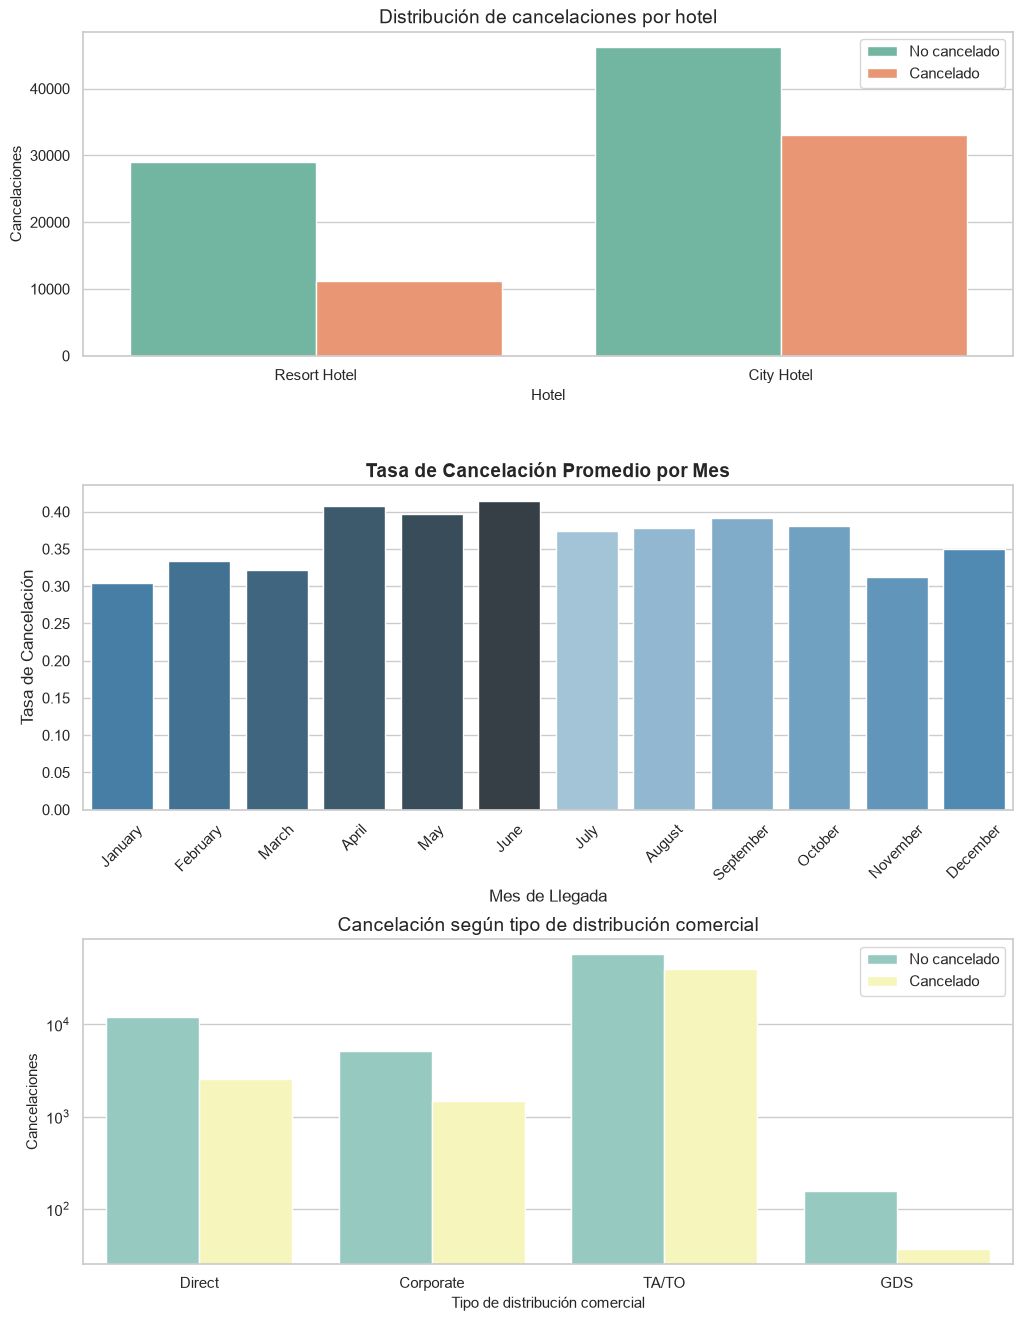

In [8]:
#Distribuciones de cancelaciones por hotel, mes y canal de distribución

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

fig, axes = plt.subplots(3, 1, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4)

#Tipo de hotel. Qué tipo de hotel recibe más cancelaciones

sns.countplot(data=df, x='hotel', hue='is_canceled', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Hotel', fontsize=11)
axes[0].set_ylabel('Cancelaciones', fontsize=11)
axes[0].set_title('Distribución de cancelaciones por hotel', fontsize=14)
axes[0].legend(['No cancelado', 'Cancelado'])

#por mes. Qué meses reciben más cancelaciones.

ordenar_meses=['January', 'February', 'March', 'April', 'May', 'June', 
                 'July', 'August', 'September', 'October', 'November', 'December']

sns.barplot(data=df, x='arrival_date_month', y='is_canceled', hue='arrival_date_month', 
            legend=False, order=ordenar_meses, ax=axes[1], errorbar=None, palette='Blues_d')
axes[1].set_title('Tasa de Cancelación Promedio por Mes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes de Llegada')
axes[1].set_ylabel('Tasa de Cancelación')
axes[1].tick_params(axis='x', rotation=45)

#por canal de distribución. Travel Agents, tour operators, Direct, Corporate y GDS son las distribuciones comerciales más importantes.
#Eliminamos Undefined porque son apenas 5 registros y no tienen valor de negocio

df_filtrado=df[df['distribution_channel']!='Undefined']

#además, como la cantidad de reservas hechas por GDS es muy pequeña, no se apreciaría en pantalla, así que tenemos que 
#escalar el eje y.

sns.countplot(data=df_filtrado, x='distribution_channel', hue='is_canceled', ax=axes[2], palette='Set3')
axes[2].set_yscale('log')
axes[2].set_title('Cancelación según tipo de distribución comercial', fontsize=14)
axes[2].set_xlabel('Tipo de distribución comercial', fontsize=11)
axes[2].set_ylabel('Cancelaciones', fontsize=11)
axes[2].legend(['No cancelado', 'Cancelado'])

En estos tres gráficos obtenemos información relevante para comprender qué queremos predecir: cuál es la probabilidad de que un cliente cancele su reserva. Es por eso que necesitamos conocer cuestiones acerca de las cancelaciones como tal. 
En el primer gráfico, analizamos los dos tipos de hoteles que aparecen en el dataset, City Hotel y Resort Hotel. Como podemos observar, las reservas en el City Hotel son más propensas a ser canceladas que las reservas del Resort Hotel, probablemente porque los clientes de este tipo de hotel pasan estancias más cortas, con un perfil más corporativo, mientras que en los Resort Hotel el perfil del cliente es más familiar, y las vacaciones están mejor planeadas que un viaje de negocio.
En el segundo gráfico analizamos la estacionalidad, los meses con mayor cancelaciones son abril, mayo y junio, justo un poco antes de verano, llegando incluso a superar el 40%, como podemos observar en los meses de abril y junio. Esto sucede porque la gente reserva sus vacaciones para el verano, pero siguen mirando para comparar precios. Sería interesante aplicar algún tipo de política de cancelación más estricta (como por ejemplo, que la reserva no fuera reembolsable).
En el tercero vemos que las reservas realizadas a través de agencias de viajes y turoperadores tienen más probabilidad de ser canceladas que las reservas hechas directamente al hotel. Por lo tanto, sería interesante incentivar la reserva directa con el hotel.

## 1.2. Análsis del comportamiento de los clientes

Text(0, 0.5, 'Tiempo previo a la entrada')

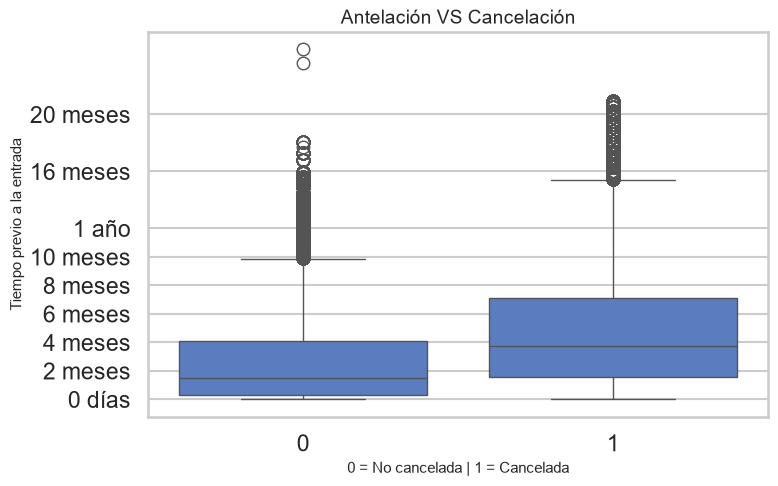

In [9]:
#relación entre lead_time (tiempo de espera entre que realizas la reserva y el día del check-in) y tasa de cancelación

posiciones_dias = [0, 60, 120, 180, 240, 300, 360, 480, 600]
etiquetas_meses = ['0 días', '2 meses', '4 meses', '6 meses', '8 meses', '10 meses', '1 año', '16 meses', '20 meses']

sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)
plt.yticks(ticks=posiciones_dias, labels=etiquetas_meses)

sns.boxplot(data=df, x='is_canceled', y='lead_time')
plt.title('Antelación VS Cancelación', fontsize=14)
plt.xlabel('0 = No cancelada | 1 = Cancelada', fontsize=11)
plt.ylabel('Tiempo previo a la entrada', fontsize=11)

Este gráfico nos ayuda a comprender con qué antelación los clientes cancelan o no sus reservas. Vemos en la caja de la derecha, la mediana del grupo de reservas canceladas se sitúa cerca de los cuatro meses, mientras que la caja del grupo de no canceladas, se sitúa por debajo de los dos meses. También vemos que hay valores atípicos, reservas realizadas con más de un año de antelación.
A modo de conclusión podemos confirmar que cuanto mayor es el tiempo que pasa entre que el cliente realiza la reserva y llega el día de hacer check-in, más probabilidad hay de que cancele la reserva. Podríamos recomendar enviar recordatorios al cliente, y aplicar cobros por adelantado.

## 1.3. Average Daily Rate.

Text(0.5, 1.0, 'Comparación entre ADR de reservas canceladas y no canceladas')

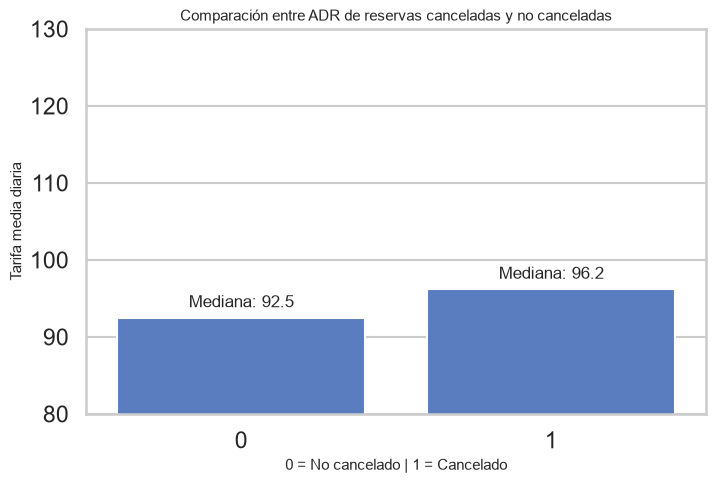

In [10]:
#comparación ADR (Average Daily Rate) medio de reservas canceladas y no canceladas

#calculamos el ADR. Primero agrupamos y luego hacemos la mediana (no usamos la media para evitar outliners) 
adr_mediana= df.groupby('is_canceled')['adr'].agg('median')
#print(adr_mediana)

ax=sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

plt.ylim(80,130)

ax=sns.barplot(x=adr_mediana.index, y=adr_mediana)

for p in ax.patches:
    ax.annotate(
        f'Mediana: {p.get_height():.1f}',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points',
        fontsize=12
    )

plt.xlabel('0 = No cancelado | 1 = Cancelado', fontsize=11)
plt.ylabel('Tarifa media diaria', fontsize=11)
plt.title('Comparación entre ADR de reservas canceladas y no canceladas', fontsize=11)


Las reservas que se han cancelado tienen una tarifa media diaria más cara que las reservas no canceladas. Es evidente que el factor monetario es un elemento clave en la cancelación de las reservas.

## 1.4. Clientes leales VS clientes que no lo son.

(0.0, 0.45983909900069214)

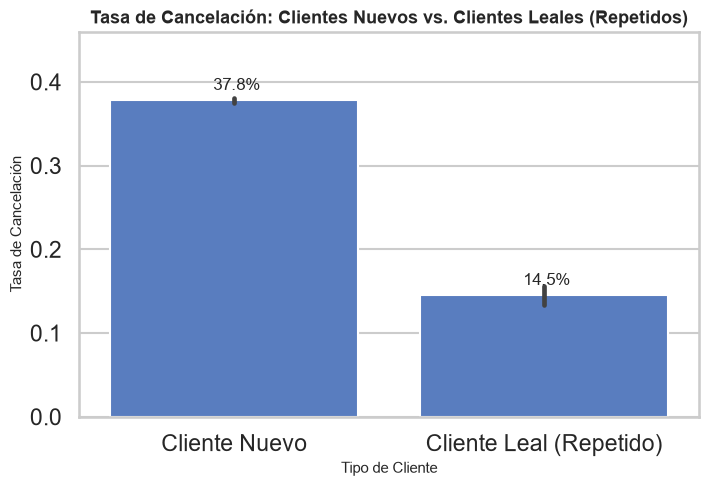

In [11]:
#ahora queremos saber si un cliente leal podría cancelar en algún momento

ax=sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)   

ax=sns.barplot(data=df, x='is_repeated_guest', y='is_canceled', estimator='mean')
for p in ax.patches:
    porcentaje=p.get_height()*100
    ax.annotate(
        f'{porcentaje: .1f}%',
        (p.get_x()+p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0,5),
        textcoords='offset points',
        fontsize=12
    )

plt.title('Tasa de Cancelación: Clientes Nuevos vs. Clientes Leales (Repetidos)', fontsize=13, fontweight='bold')
plt.xlabel('Tipo de Cliente', fontsize=11)
plt.ylabel('Tasa de Cancelación', fontsize=11)
plt.xticks([0, 1], ['Cliente Nuevo', 'Cliente Leal (Repetido)'])
plt.ylim(0, ax.get_ylim()[1] * 1.15)

En este gráfico no hay grandes sorpresas, pero es interesante tenerlo en cuenta. Un cliente leal, que ya ha estado en el hotel, probablemente no va a cancelar la reserva, mientras que un cliente nuevo, sí puede cancelarla. Por eso es importante considerar algún sistema de retribución, es decir, premiar al cliente que repite.

## 1.5. ¿Los cambios en la reserva condicionan la cancelación?

(0.0, 0.5)

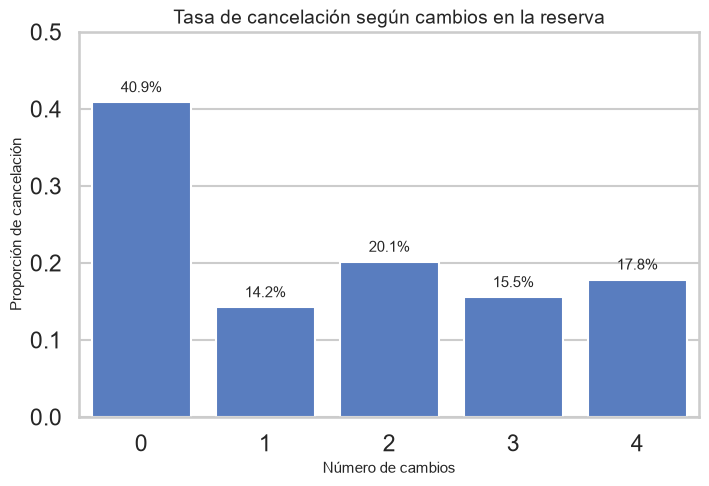

In [12]:
#el siguiente gráfico muestra si el haber cambios en la reserva condiciona la cancelación

sns.set_theme (
    style = 'whitegrid',
    palette = 'muted',
    context = 'talk',
    rc = {
        'figure.figsize' : (8,5),
        'axes.titlesize' : 16,
        'axes.labelsize' : 12
    },
)

ax=sns.barplot(data=df[df['booking_changes']<5], x='booking_changes', y='is_canceled', estimator='mean', errorbar=None)


for p in ax.patches:
    porcentaje = p.get_height() * 100
    ax.annotate(
        f'{porcentaje:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11
    )


plt.title('Tasa de cancelación según cambios en la reserva', fontsize=14)
plt.xlabel('Número de cambios', fontsize=11)
plt.ylabel('Proporción de cancelación', fontsize=11)
plt.ylim(0, 0.5)

Pues no. Vemos que el cliente que cancela, no realiza ningún cambio en la reserva. Simplemente cancela. Los clientes que piden realizar algún cambio, por lo general, solucionan cualquier cuestión y no necesitan cancelar (aunque cancelaciones siempre hay, pero vemos que se reduce incluso por debajo de la mitad), pues muestran de esta manera compromiso e intención activa por el viaje.

# 2. FEATURE ENGINEERING: 
## Transformar y combinar variables crudas para que los modelos predictivos puedan capturar patrones más complejos.

In [ ]:
df['complete_stay']=df['stays_in_weekend_nights']+df['stays_in_week_nights']

Combinamos el número de noches y el número de días para obtener el tiempo total que pasa el huésped en el hotel.
Las estancias largas implican un mayor compromiso con la reserva.

In [ ]:
df['total_cost']=df['complete_stay']*df['adr']

Representa el valor monetario de la duración total de la estancia.
El huésped es sensible al precio total de la estancia. Si encuentra una opción más barata, probablemente cancele la reserva.

In [ ]:
df['total_guests']=df['adults']+df['children']+df['babies']

Condensamos tres variables técnicas en una sola, que mida la dimensión real del grupo.
Los viajes en grupo suponen mayor complejidad en la organización, y de ésto dependerán los patrones de cancelación.

In [ ]:
df['has_changes']=(df['booking_changes']>0).astype(int)

Convertimos booking_changes en un indicador binario.
No necesitamos saber cuántos cambios se han realizado, sino si hay cambios o no.

In [17]:
#pasamos total_of_special_requests a binario
df['has_requests']=(df['total_of_special_requests']>0).astype(int)

Convertimos total_of_special_request en un indicador binario.
El hecho de que el cliente haya solicitado un requerimiento especial refleja que tiene compromiso con la reserva, y conocer esto es fundamental para predecir la probabilidad de cancelación.

Una vez que hemos creado las variables que utilizaremos para entrenar el modelo, seguimos con el encoding.


In [ ]:
#ONE-HOT ENCODING

#eliminamos las variables "chivatas"
if 'reservation_status' in df.columns:
    df = df.drop(columns=['reservation_status'])
if 'reservation_status_date' in df.columns:
    df = df.drop(columns=['reservation_status_date'])

#como country tiene una alta cardinalidad (más de 170 países), vamos a agruparlo  
#para ello, nos quedamos con el top 10 países que más reservas hacen

if 'country' in df.columns:
    top_10=df['country'].value_counts().head(10).index #obtenemos el valor de los 10 países con más reservas
    df['country_group']=df['country'].apply(lambda x: x if x in top_10 else 'other') #revisamos fila por fila el nombre de los países,
    #si está dentro de la lista, se deja tal cual, si no, se cambia a 'other'

    df=df.drop(columns=['country']) #eliminamos la columna country y dejamos country_group

#seleccionamos solo las columnas de texto/objeto
cols_text = df.select_dtypes(include=['object', 'category']).columns

#vemos cuántos valores únicos tiene cada una
categorical_cols=[col for col in cols_text if df[col].nunique() <= 12] #para tener todos los meses del año

df_encoded=pd.get_dummies(df,columns=categorical_cols, drop_first=True, dtype=int)

#df_encoded.head(5)
    

Eliminación de variables para evitar data leakage (reservation_status, reservation_status_date). Si las hubiésemos dejado, el entrenamiento estaría completamente entrampado, pero habría resultado completamente inútil en producción porque cuando se hace la reserva, no existe esta información.
Agrupamos country en country_group, ya que country tiene una alta cardinalidad. Al agrupar los países en un top 10 (que además, son los países que más reservas hacen), y al relegar a los demás en la categoría "other", reducimos drásticamente el riesgo de overfitting.
Por último, aplicamos pd.get_dummies sobre variables cualitativas acotadas (doce o menos niveles). Además, utilizamos drop_first=True para prevenir la multicolinealidad y adecuar la matriz de características para XGBoost como para modelos lineales baselines.

In [ ]:
"""
eliminamos las columnas que no son relevantes para nuestra predicción y que además ya hemos utilizado en la creación de variables
nuevas.
"""
delete_columns =[
    'arrival_date_year', 
    'arrival_date_day_of_month' 
    'stays_in_weekend_nights',
    'stays_in_week_nights', 
]

"""
eliminamos las columnas que empiezan con assigned_room_type porque es lo mismo que reserved_room_type y además, 
esta variable nos confirmaría que la reserva se ha realizado (data leakage)
"""

cols_assigned = [col for col in df_encoded.columns if col.startswith('assigned_room_type_')] 
cols_delete = [c for c in (delete_columns + cols_assigned) if c in df_encoded.columns]

df_final = df_encoded.drop(columns=cols_delete)

In [ ]:
#Comprobamos que están todas las columnas que nos interesan
df_final.columns

In [ ]:
"""
antes de empezar con el entrenamiento, tenemos que gestionar los valores nulos primero, agent y company. 
Cambiar los nulos por 0 significa que la reserva se hizo sin agente o empresa externoses decir, fue una reserva 
directamente con el hotel. También, gestionamos los nulos en la columna children y la columna babies. 
Simplemente, cuando el valor es nulo, significa que no hay niños, ni bebés.
"""

if 'agent' in df_final.columns:
    df_final['agent']=df_final['agent'].fillna(0)

if 'company' in df_final.columns:
    df_final['company']=df_final['company'].fillna(0)

if 'children' in df_final.columns:
    df_final['children']=df_final['children'].fillna(0)

if 'babies' in df_final.columns:
    df_final['babies']=df_final['babies'].fillna(0)

nulos_restantes = df_final.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {nulos_restantes}")

Total de valores nulos en el dataset: 0


In [ ]:
"""
Después de ejecutar el bloque de código anterior, me doy cuenta de que aún tenía valores nulos. Después de hacer algunas pruebas,
compruebo que aún tenía valores nulos, decido solucionarlo de esta manera, en el dataset final (para evitar más complicaciones teniendo 
en cuenta que trabajo 40h semanales)
"""
#df_final['total_guests'] = df_final['adults'] + df_final['children'].fillna(0) + df_final['babies'].fillna(0)

# 3. CONJUNTO DE ENTRENAMIENTO Y PRUEBA(TRAIN/TEST)
## Una vez que hemos comprobado que nuestro dataset ya está limpio, continuamos con el entrenamiento del modelo.

Cuando hice las primeras pruebas del entrenamiento, obtenía unos resultados horribles. Al consultarlo con la IA, me sugirió que la manera de arreglarlo era ordenar el dataset por la fecha de llegada antes de hacer la partición temporal sin shuffle.
A pesar de que comprobé el inicio y el final del dataset (2015 al inicio, 2017 al final), el problema estaba en la estructura interna, y es que los datos venían agrupados en bloques por estado de cancelación, por eso, necesitamos forzar la reordenación por año, mes y día.

In [ ]:
# Crearmos un índice temporal basado en las columnas de fecha originales
df_final['temp_year'] = df['arrival_date_year']

# Mapeo simple de meses a números
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}

df_final['temp_month'] = df['arrival_date_month'].map(month_map)
df_final['temp_day'] = df['arrival_date_day_of_month']

# Ordenar cronológicamente
df_final = df_final.sort_values(by=['temp_year', 'temp_month', 'temp_day']).reset_index(drop=True)

# Limpiar las columnas temporales auxiliares
df_final = df_final.drop(columns=['temp_year', 'temp_month', 'temp_day'])

In [ ]:
#teniendo en cuenta que nuestra variable objetivo es is_canceled, la separamos de las demás
#también tenemos que tener en cuenta que debemos trabajar con las fechas

#verificamos que el dataset final sigue ordenado (el dataset original viene por orden cronológico)
is_ordered=df_final.index.is_monotonic_increasing

#separamos la matriz x de la variable objetivo y
X=df_final.drop(columns=['is_canceled']) #guardamos en x todas las variables excepto is_canceled, que la eliminamos
y=df_final['is_canceled'] #la guardamos aquí, porque es nuestra variable objetivo

X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.20, #80-20
    shuffle=False #el dataset ya está ordenado
)
#usamos robustscaler para evitar los outliners que vimos que tenía el dataset, ya que este escalador utiliza la mediana y el rango
#intercuartílico

#filtramos las variables continuas y las diferenciamos de las variables binarias ya codificadas
scale_cols=[col for col in X_train.columns if X_train[col].nunique() > 2]
#escalamos
scaler=RobustScaler()

X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[scale_cols]=scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols]=scaler.transform(X_test[scale_cols])

print(f"Train (pasado): {X_train_scaled.shape[0]} filas")
print(f"Test (futuro):  {X_test_scaled.shape[0]} filas")


Train (pasado): 95512 filas
Test (futuro):  23878 filas


## 3.1. Regresión logística

Utilizamos la regresión logística como nuestro modelo base del proyecto. Esto significa que los otros modelos que entrenemos tienen que superar los resultados. La regresión logística asume relaciones lineales directas entre las variables y el riesgo.
Hemos escalado datos porque de esta manera aseguramos que ninguna variable domine sobre las demás. Por último, hacemos la predicción del conjunto de los datos. 

In [ ]:
#REGRESIÓN LOGÍSTICA interpretable como referencia

baseline_model=LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train) #entrenamiento

y_pred=baseline_model.predict(X_test_scaled)
#extrae la probabilidad continua (0.0-1) de que la reserva sea cancelada
y_pred_proba=baseline_model.predict_proba(X_test_scaled)[:,1] 

print("--- Informe de Clasificación (Baseline) ---")
#mostramos precisión, recall y F1-score
print(classification_report(y_test, y_pred))
#medimos la capacidad del modelo para separar las reservas que se cancelan o no, sin tener en cuenta el umbral.
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Probamos otros modelos para comprobar si son superiores a la regresión logística. Los modelos más comunes para analizar el sector hotelero son los modelos de árboles, ya que no requieren escalado estricto y manejan interacciones complejas de manera nativa. 

Vamos a probar con un random forest, aunque, según lo comentado por mis compeñeros de clase en el grupo de whatsapp, 
no es la mejor opción, pero quiero comprobarlo, porque es uno de los más utilizados:

## 3.2. Random forest

A diferencia de la regresión logística, este algoritmo promedia múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos y variables.

In [ ]:
#random forest

#empezamos el entrenamiento
rf_model = RandomForestClassifier(
    n_estimators=100, #100 árboles de decisión independiente, de forma paralela
    random_state=42, #fijamos la semilla para asegurar la reproducibilidad exacta
    n_jobs=1 #un único núcleo de procesamiento para el cálculo
)
#entrenamos sin scalar
rf_model.fit(X_train, y_train)

y_pred_rf=rf_model.predict(X_test)
y_pred_proba_rf=rf_model.predict_proba(X_test)[:,1]


print("--- Informe de Clasificación (Random Forest) ---")
#Evaluamos el rendimiento, igual que con la regresión logística
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

#vemos que da mejores resultados que la regresión logística.

El modelo Random Forest da mejores resultados que la regresión logística, debido a su capacidad para capturar umbrales no lineales y dividir las reservas en función de la combinación de variables. Es por eso que, a continuación, utilizaremos XGBoost para maximizar el rendimiento de la predicción.

## 3.3. XGBoost

Este tipo de modelo aprende en cadena, es decir, cada nuevo árbol de decisión que se crea, se centra en solucionar los errores que los árboles anteriores han cometido, a diferencia del Random Forest, que entrena los árboles de manera independiente al mismo tiempo y promedia sus votos.

In [ ]:
xgb_model=XGBClassifier(
    n_estimators=100, #creamos los árboles, de forma secuencial
    learning_rate=0.1, #controlamos el ritmo al que aprende el modelo
    max_depth=6, #profundidad máxima de cada árbol
    random_state=42, #misma semilla
    n_jobs=1 #un núcleo de procesamiento
)

xgb_model.fit(X_train, y_train)

y_pred_xgb=xgb_model.predict(X_test)
y_pred_proba_xgb=xgb_model.predict_proba(X_test)[:,1]

print("--- Informe de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

Vemos que podemos seguir sacándole punta a la predicción.

### 3.3.1 Optimización de XGBoost

También podemos optimizar los hiperparámentros de XGBoost utilizando RandomizedSearchCV. De esta manera estamos buscando el rendimiento máximo posible para nuestra predicción, antes de pasar a la interpretabilidad final con SHAP. RandomizedSearchCV sirve para probar combinaciones posibles, pero de manera acotada, de esta manera, no necesitamos tanto tiempo.

In [ ]:
"""
dividimos el número de reservas no canceladas entre las canceladas. De esta manera avisamos a XGBoost de que el dataset
no está equilibrado
"""
pos_weight = float((y_train == 0).sum() / (y_train == 1).sum()) 

#definimos los parámetros que vamos a probar
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1.0, pos_weight]
}

#configuramos RandomizedSearchCV
xgb_base = XGBClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3, #validación cruzada
    random_state=42,
    n_jobs=-1 #aquí usamos todos los núcleos del procesador para ir lo más rápido posible
)

#entrenamos el modelo
random_search.fit(X_train, y_train)

#guardamos la mejor combinación
best_xgb = random_search.best_estimator_
print("Mejores Hiperparámetros Encontrados:")
print(random_search.best_params_)

#evaluación final del entrenamiento
y_pred_best = best_xgb.predict(X_test)
y_pred_proba_best = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Informe de Clasificación (XGBoost Optimizado) ---")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC Score Final: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

# 4. INTERPRETABILIDAD: SHAP



Esta librería sirve para explicar e interpretar las predicciones de los modelos de machine learning

## 4.1 Summary Plot

Muestra la importancia  global de las variables y cómo afectan positiva o negativamente al riesgo de cancelación.

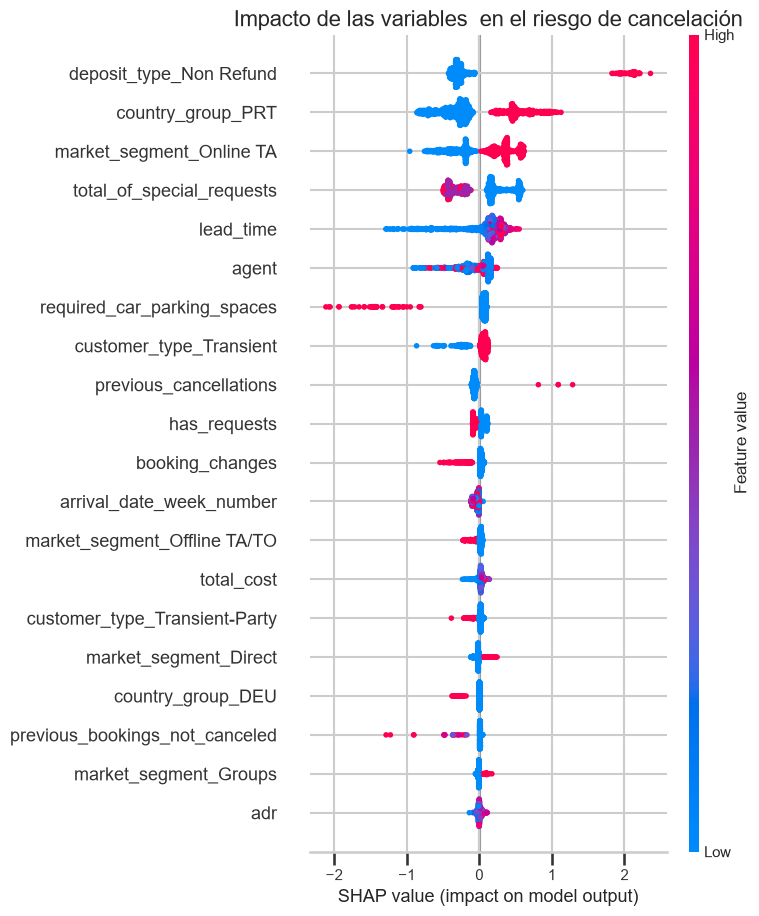

In [29]:
#creamos el explicador de shap
explainer=shap.TreeExplainer(best_xgb)

#muestra representativa
X_test_sample=X_test.sample(1000, random_state=42)

#calcular valores shap
shap_values=explainer(X_test_sample)

#generar summary plot
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("Impacto de las variables  en el riesgo de cancelación")
plt.tight_layout()
plt.show()

La variable más determinante es deposit_type_Non Refound. Los puntos rojos se encuentran muy a la derecha, esto significa que, cuando el depósito no es reembolsable, incrementa enormemente el riesgo de cancelación. Otra variable muy determinante es country_group_PRT. Los puntos rojos vuelven a encontrarse muy a la derecha. Los clientes locales tienen un impacto directo en el aumento del riesgo de cancelación. La siguiente determinante es total_of_special_request. Aquí vemos que ocurre lo contrario: los puntos están a la izquierda, mientras que los azules a la derecha. Cuantas más peticiones haga el cliente (puntos rojos), menos probabilidad hay de que cancele el viaje. Otra variable: required_car_parking_spaces. Solicitar una plaza de aparcamiento es una de las señales más fuertes de reserva segura (puntos rojos hacia la derecha). Por último, lead_time. Puntos rojos desplazados a la derecha, a mayor tiempo de antelación de la reserva, mayor riesgo de cancelación. Puntos azules se deplazan a la izquierda, esto significa que las reservas de última hora se cancelan menos. 

## 4.2 Waterfall plots

Por último

Probabilidad de cancelación (Alto Riesgo): 89.08%


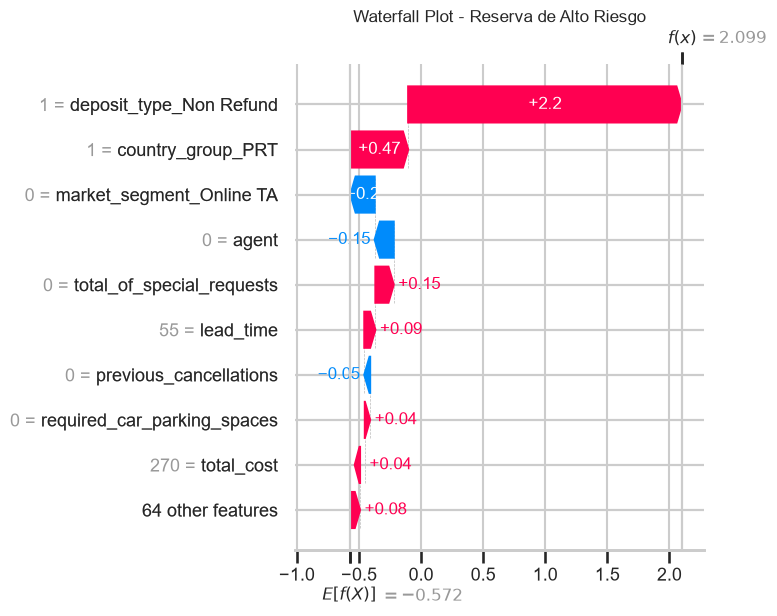

Probabilidad de cancelación (Bajo Riesgo): 19.52%


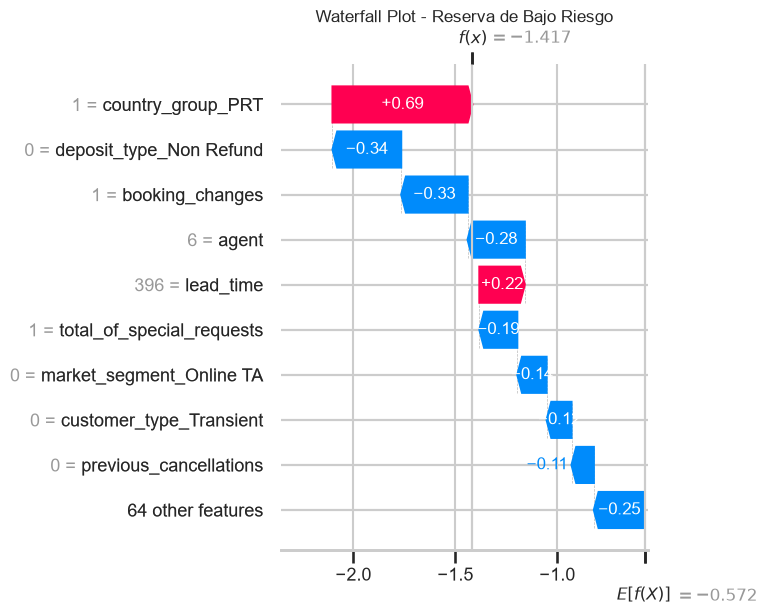

In [31]:
explainer=shap.TreeExplainer(best_xgb)
shap_values_sample=explainer(X_test_sample)

probs=best_xgb.predict_proba(X_test_sample)[:,1]

#gráfico para la reserva con alto riesgo de cancelación

high_risk_idx=(probs>0.8).nonzero()[0][0] #reserva con alto riesgo de cancelación

print(f"Probabilidad de cancelación (Alto Riesgo): {probs[high_risk_idx]:.2%}")
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_sample[high_risk_idx], max_display=10, show=False)
plt.title("Waterfall Plot - Reserva de Alto Riesgo", fontsize=12)
plt.tight_layout()
plt.show()

#gráfico para la reserva con bajo riesgo de cancelación

low_risk_idx=(probs<0.2).nonzero()[0][0] #reserva con bajo riesgo de cancelación

print(f"Probabilidad de cancelación (Bajo Riesgo): {probs[low_risk_idx]:.2%}")
plt.figure(figsize=(9, 6))
shap.plots.waterfall(shap_values_sample[low_risk_idx], max_display=10, show=False)
plt.title("Waterfall Plot - Reserva de Bajo Riesgo", fontsize=12)
plt.tight_layout()
plt.show()